In [4]:
#Import Modules
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import truncnorm

Parameters:
1. Number Of Agents
2. Number of levels? Departments? Company Structure
3. Base Game Payoffs
4. Base Productivity
5. Initial Conditions: Integrity, Trust


In [5]:
class Agent: 
    def __init__(self, id, level, integrity, trust):
        self.id = id
        self.level = level
        self.integrity = integrity
        self.trust = trust
        self.utility = 0.0
        self.strategy = 1
        self.history = []
        self.bosses = []
        self.peers = []
        self.underlings = []



Option 1: generate agents with network
Option 2: generate network then add agents
Option 3: generate agents then generate network

In [ ]:
def generate_network(level_size, integrity_mean, trust_mean):
    G = nx.DiGraph()
    ceo = Agent(0, 'CEO', truncnorm.rvs(-1, 1, loc=integrity_mean, scale=1), truncnorm.rvs(-1, 1, loc=trust_mean, scale=1))
    G.add_node(ceo.id, level=0, agent=ceo)
    nodes_this_level = [ceo.id]
    for level, size in enumerate(level_size):
        nodes_level = []
        for employee in range(size):
            id = len(G.nodes)
            this_level = level + 1
            integrity = truncnorm.rvs(-1, 1, loc=integrity_mean, scale=1)
            trust = truncnorm.rvs(-1, 1, loc=trust_mean, scale=1)
            agent = Agent(id, this_level, integrity, trust)
            G.add_node(agent.id, level=this_level, agent=agent)
            nodes_level.append(agent)
            
            if this_level == 1:
                G.add_edge(0, agent.id)
                agent.bosses.append(ceo.id)
                ceo.underlings.append(agent.id)
            else:
                boss_id = np.random.choice([n for n, d in G.nodes(data=True) if d['level'] == this_level - 1])
                G.add_edge(boss_id, agent.id)
                agent.bosses.append(boss_id)
                G.nodes[boss_id]['agent'].underlings.append(agent.id)
        nodes_this_level.append(nodes_level)
        for employee in nodes_this_level[-1]:
            for peer in nodes_this_level[-1]:
                if employee != peer:
                    G.add_edge(employee.id, peer.id)
                    G.add_edge(peer.id, employee.id)
                    employee.peers.append(peer.id)
                    peer.peers.append(employee.id)
    return G

In [35]:
def initialize(level_size = [3, 9], integrity_mean=0, trust_mean=0):


    G = generate_network(level_size, integrity_mean, trust_mean)
    return G

In [36]:
def plot_network(G):
    pos = nx.kamada_kawai_layout(G)
    levels = np.array([G.nodes[n]['level'] for n in G.nodes])
    integrities = np.array([G.nodes[n]['agent'].integrity for n in G.nodes])
    sizes = 1800 / (levels + 1)
    plt.figure(figsize=(10, 7))
    nx.draw_networkx_edges(G, pos, alpha=0.35, arrows=True, arrowstyle='-|>', arrowsize=12)
    nodes = nx.draw_networkx_nodes(G, pos, node_color=integrities, node_size=sizes, cmap='RdYlGn', vmin=-1, vmax=1)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.colorbar(nodes, label='Integrity')
    plt.axis('off')
    plt.show()

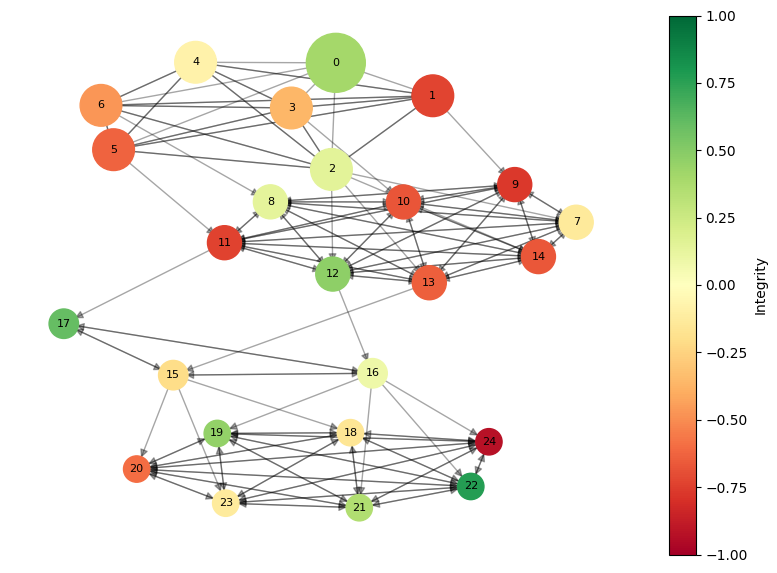

In [37]:
G = generate_network([6, 8, 3, 7])
plot_network(G)


agents ascribe strategy to all underlying based on perceptions
--> ascribe strategy to peers based on perceptions
--> ascribe strategy to superiors based on perceptions
Strategy expected payoffs are based on integrity, trust, and perceptions of others' strategies
cooperate cooperate results outcome: highest productivity for company
pay of boss is based on productivity of underlings 

agents update trust based on: person they can see (connected too) with highest utility: if that person is cooperating, they increase trust, if that person is defecting, they decrease trust.

agents update integrity on longer time scale (add later)

perception of others' strategies based on: trust (and history of interactions with them (add later))